In [ ]:
#HDDM N-back script using bayesian MCMC to converge on set of parameters. We use the baseline model from https://www.sciencedirect.com/science/article/pii/S2451902222000787 and make variations for model validation.

# Load packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import hddm
from joblib import Parallel, delayed

In [ ]:
import hddm
import numpy as np
import pandas as pd
import arviz as az

def fit_subject_hddm_with_convergence(data, chains=3):
    """
    Fits HDDM (non-hierarchical) for each subject using multiple chains and computes R-hat.
    """
    rhat_results_list = []
    trace_results_list = []

    for subj_idx in np.unique(data['subj_idx']):
        subj_data = data[data['subj_idx'] == subj_idx]

        chain_traces = []

        print(f"\nFitting subject {subj_idx} with {chains} chains...")

        for c in range(chains):
            print(f"  Chain {c+1}")

            m = hddm.HDDM(
                subj_data,
                depends_on={'v':'stim', 'z':'stim', 'a':'stim','t':'stim'},
                include=['z', 'sz', 'st',],
                p_outlier=0.05
            )

 #           m.find_starting_values()
            m.sample(2000, burn=1000)
            chain_traces.append(m.get_traces())

        # Stack traces into dict of lists for ArviZ
        param_names = chain_traces[0].columns
        trace_dict = {
            param: [trace[param].values for trace in chain_traces]
            for param in param_names
        }

        # Convert to InferenceData object for convergence checking
        idata = az.from_dict(posterior=trace_dict)
        rhat = az.rhat(idata)

        # Save R-hat values
        for param, value in rhat.items():
            rhat_results_list.append({
                'subj_idx': subj_idx,
                'param': param,
                'rhat': float(value)
            })

        # Save trace means (e.g., chain 0 — or you can average across chains here)
        mean_traces = chain_traces[0].mean()
        for param in mean_traces.index:
            trace_results_list.append({
                'subj_idx': subj_idx,
                'param': param,
                'mean_trace_value': mean_traces[param]
            })

    return pd.DataFrame(trace_results_list), pd.DataFrame(rhat_results_list)

# Load and prepare data
data = pd.read_csv("simple_ddm_param_recovery.csv").dropna()
data['rt'] = data['rt'] * (2 * data['response'] - 1)  # signed RTs for HDDM

# Run model
df_traces, df_rhat = fit_subject_hddm_with_convergence(data)

# Save outputs
df_traces.to_csv('hddm_vanilla_traces.csv', index=False)
df_rhat.to_csv('hddm_vanilla_rhat.csv', index=False)


In [ ]:
import pandas as pd

# Load the data
df = pd.read_csv("hddm_vanilla_traces.csv")  # replace with actual filename if needed

# Pivot to wide format
pivoted_df = df.pivot(index='subj_idx', columns='param', values='mean_trace_value').reset_index()

# Save or view
pivoted_df.to_csv("pivoted_traces.csv", index=False)
print(pivoted_df.head())


In [ ]:
import hddm
import numpy as np
import pandas as pd
import arviz as az

def fit_combined_hddm_model(data, chains=4):
    """
    Fits a combined (pooled) HDDM model and returns DIC, R-hat, and trace summaries.
    """
    rhat_results_list = []
    trace_results_list = []

    print("\nFitting combined (non-hierarchical) HDDM model...")

    chain_traces = []

    for c in range(chains):
        print(f"  Chain {c+1}")

        m = hddm.HDDM(
            data,
            depends_on={'v':'stim', 'a':'stim', 't':'stim'},
            include=['z'],
            p_outlier=0.05
        )
        m.sample(2000, burn=1000)
        chain_traces.append(m.get_traces())

    # Combine traces for ArviZ
    param_names = chain_traces[0].columns
    trace_dict = {
        param: [trace[param].values for trace in chain_traces]
        for param in param_names
    }

    # Convert to arviz InferenceData
    idata = az.from_dict(posterior=trace_dict)

    # Compute R-hat
    rhat = az.rhat(idata)

    # Save R-hat results
    for param, value in rhat.items():
        rhat_results_list.append({
            'param': param,
            'rhat': float(value)
        })

    # Save trace means from first chain (or average if desired)
    mean_traces = chain_traces[0].mean()
    for param in mean_traces.index:
        trace_results_list.append({
            'param': param,
            'mean_trace_value': mean_traces[param]
        })

    # Get DIC from last model fitted
    dic_value = m.dic
    dic_df = pd.DataFrame([{"dic": dic_value}])

    return pd.DataFrame(trace_results_list), pd.DataFrame(rhat_results_list), dic_df


# === Run the model ===

# Load and prepare data
data = pd.read_csv("Memory_Task_DDM.csv").dropna()
data['rt'] = data['rt'] * (2 * data['response'] - 1)  # signed RTs for HDDM

# Run combined model
df_traces, df_rhat, df_dic = fit_combined_hddm_model(data)

# Save outputs
df_traces.to_csv('combined_hddm_traces.csv', index=False)
df_rhat.to_csv('combined_hddm_rhat.csv', index=False)
df_dic.to_csv('combined_hddm_dic.csv', index=False)


In [ ]:
#Depreciated 

import matplotlib
matplotlib.use('Agg')
import pandas as pd
import numpy as np
import hddm
import kabuki
from kabuki.analyze import gelman_rubin
import sys

try:
    i = int(sys.argv[1])
except (IndexError, ValueError):
    i = 0  # or any default fallback

print('sample#')
print(i)

dataname = f'Memory_Task_DDM.csv'
data = pd.read_csv(dataname)
data = data.dropna()

models = []
for a in range(3):
  m = hddm.HDDM(data,include=['z','st'],p_outlier=0.05)
  m.find_starting_values()
  m.sample(2000,burn=1000,dbname='model'+str(i)+'_'+str(a)+'traces.db',db='pickle')
  models.append(m)
#combine models
combined_model = kabuki.utils.concat_models(models)
#dic
dic_value = combined_model.dic
print(f"DIC: {dic_value}")
with open(f'dic_model_{i}.txt', 'w') as f:
    f.write(f"DIC: {dic_value}")
#convergence
gelman = gelman_rubin(models)
gelman = pd.DataFrame.from_dict(gelman,orient='index')
convergencename = 'convergence_model_%s.csv'%(i)
gelman.to_csv(convergencename)
#traces
traces = combined_model.get_traces()
filename = 'traces_model_%s.csv'%(i)
traces.to_csv(filename)
#stats
combined_model.print_stats(fname='stats_model_%s.csv'%(i))
#model
combined_model.save('model_%s'%(i))
#ppc
ppc_data_append = hddm.utils.post_pred_gen(combined_model,append_data=True,samples=10)
ppc = ppc_data_append.reset_index()
ppc.to_csv('ppc_model_%s.csv'%(i))

import pandas as pd
import re

# Load the file (no headers, whitespace-separated)
df = pd.read_csv("stats_model_0.csv", delim_whitespace=True, header=None)

# Name the columns (assume HDDM default order + one extra column like mc_err or ess)
df.columns = ['param', 'mean', 'std', '2.5q', '25q', '50q', '75q', '97.5q', 'mc_err']

# Keep only rows with subject-level parameters (those including .P###)
df = df[df['param'].str.contains(r'\.P\d{3}', regex=True)].copy()

# Extract Participant ID
df['Participant.ID'] = df['param'].str.extract(r'\.?(P\d{3})')

# Extract parameter type from prefix
def extract_param_type(param):
    if param.startswith('a_subj'):
        return 'a'
    elif param.startswith('v_subj'):
        return 'v'
    elif param.startswith('t_subj'):
        return 't'
    elif param.startswith('z_subj'):
        return 'z'
    return None

df['param_type'] = df['param'].apply(extract_param_type)

# Pivot to wide format using the 'mean' column
pivot_df = df.pivot(index='Participant.ID', columns='param_type', values='mean').reset_index()

# Save the result
pivot_df.to_csv("participant_params_pivoted.csv", index=False)

In [ ]:
import pandas as pd
import numpy as np
import hddm

# Define true DDM parameters per stimulus
true_params = {
    0: {'a': 1.5, 't': 0.15, 'v': 0.5, 'z': 0.25, 'st': 0.2, 'sz': 0.2},
    1: {'a': 2.0, 't': 0.15, 'v': 1.6, 'z': 0.25, 'st': 0.2, 'sz': 0.2}
}

def simulate_simple_ddm(true_params, trials_per_stim=100, n_subjects=10, subj_noise=0.05):
    all_data = []

    for i in range(n_subjects):
        subj_id = f"P{i+1:03d}"
        subj_trials = []

        for stim in [0, 1]:
            params = true_params[stim].copy()
            df, _ = hddm.generate.gen_rand_data(
                params=params,
                size=trials_per_stim,
                subjs=1,
                subj_noise=subj_noise
            )
            df['stim'] = stim
            df['subj_idx'] = subj_id
            df['correct'] = (df['response'] == stim).astype(int)
            subj_trials.append(df)

        all_data.append(pd.concat(subj_trials, ignore_index=True))

    return pd.concat(all_data, ignore_index=True)

# Simulate and export
df_sim = simulate_simple_ddm(true_params, trials_per_stim=100, n_subjects=300)
df_sim.to_csv("simple_ddm_param_recovery.csv", index=False)
print(df_sim.head())


In [ ]:
import pandas as pd
import hddm
import numpy as np
from scipy.special import expit  # inverse logit

# Load posterior parameter estimates
posteriors = pd.read_csv("pivoted_traces.csv").drop(columns=["condition"], errors='ignore')

# Only apply expit if z is still in logit form
posteriors['z(0)'] = expit(posteriors['z_trans(0)'])
posteriors['z(1)'] = expit(posteriors['z_trans(1)'])

# Function to simulate PPC for one subject
def simulate_posterior_predictive(subj_row, n_trials_per_stim=50, subj_noise=0.0):
    all_trials = []

    for stim in [0, 1]:
        # Extract stimulus-specific parameters
        params = {
            'a': subj_row[f'a({stim})'],
            'v': subj_row[f'v({stim})'],
            't': subj_row[f't({stim})'],
            'z': subj_row[f'z({stim})'],
            'st': subj_row['st'],
            'sz': subj_row['sz']
        }

        # Simulate trials using HDDM
        df_sim, _ = hddm.generate.gen_rand_data(
            params=params,
            size=n_trials_per_stim,
            subjs=1,
            subj_noise=subj_noise
        )

        # Add metadata
        df_sim['stim'] = stim
        df_sim['subj_idx'] = subj_row['subj_idx']
        
        
        # Define accuracy: correct if response matches stim
        # Determine the correct response for each trial based on stim
        correct_resp = 1 if params['v'] > 0 else 0
        df_sim['correct'] = (df_sim['response'] == correct_resp).astype(int)

        # Now calculate accuracy
        df_sim['correct'] = (df_sim['response'] == correct_resp).astype(int)
        all_trials.append(df_sim)

    return pd.concat(all_trials, ignore_index=True)

# Run PPC simulation for all subjects
simulated_ppc = pd.concat(
    [simulate_posterior_predictive(row) for _, row in posteriors.iterrows()],
    ignore_index=True
)

# Save simulated data
simulated_ppc.to_csv("posterior_predictive_simulation_from_subject_params.csv", index=False)

# Preview
print(simulated_ppc.head())


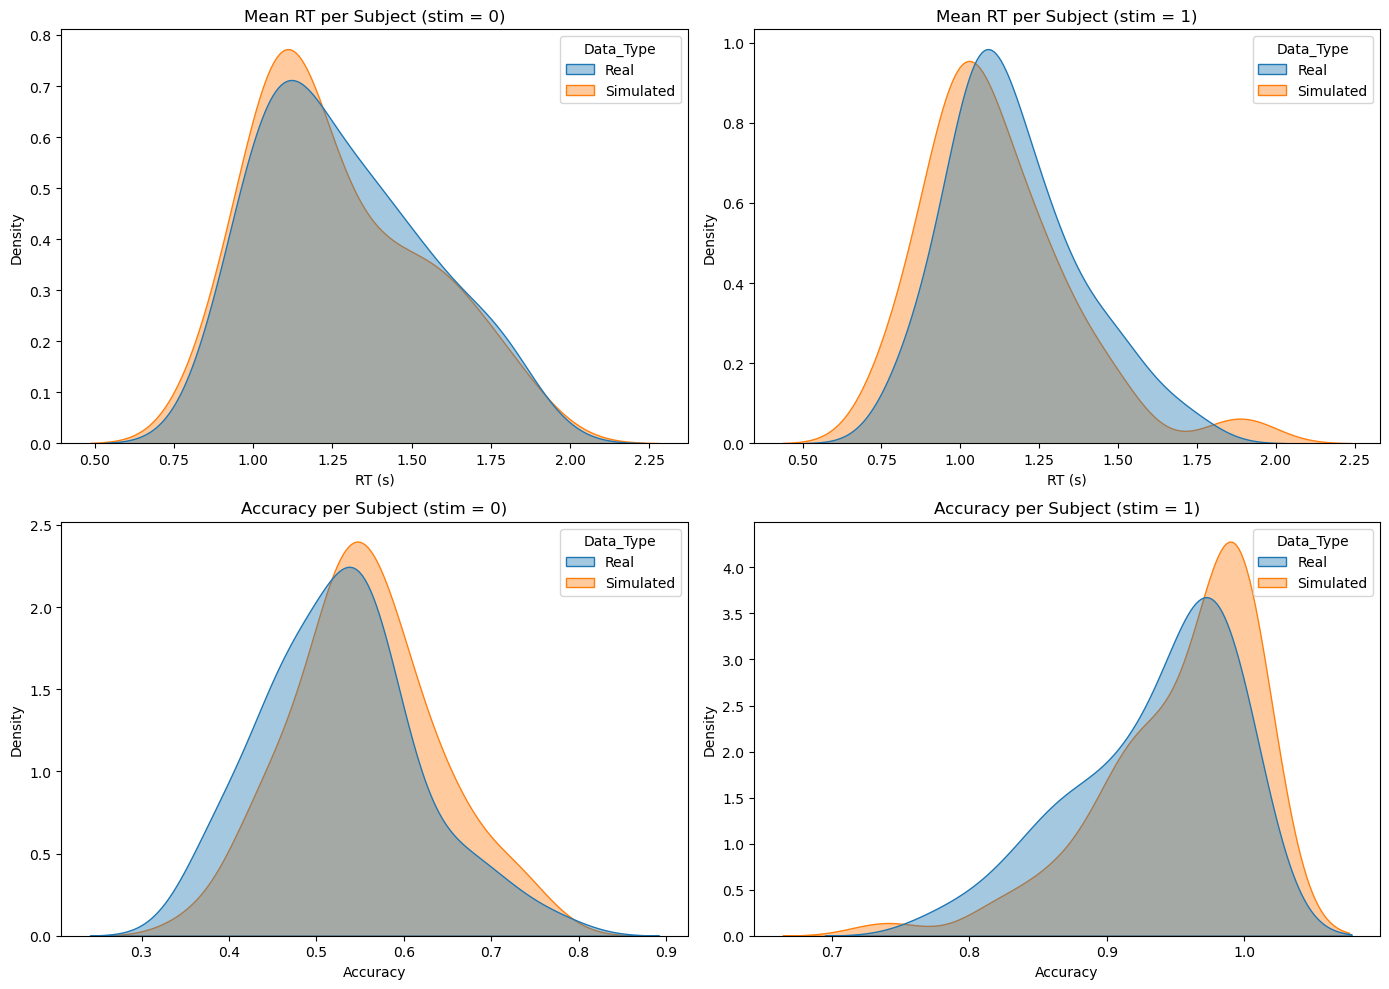

In [46]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Load real data
real_data = pd.read_csv("Memory_Task_DDM.csv")
real_data['Data_Type'] = 'Real'
real_data['correct'] = (real_data['response'] == real_data['stim']).astype(int)

# Load simulated data
sim_data = pd.read_csv("posterior_predictive_simulation_from_subject_params.csv")
sim_data['Data_Type'] = 'Simulated'

# Keep relevant columns including stim
real = real_data[['subj_idx', 'rt', 'stim', 'correct', 'Data_Type']].copy()
sim = sim_data[['subj_idx', 'rt', 'stim', 'correct', 'Data_Type']].copy()

# Combine
combined = pd.concat([real, sim], ignore_index=True)

# Clean numeric
combined['rt'] = pd.to_numeric(combined['rt'], errors='coerce')
combined['correct'] = pd.to_numeric(combined['correct'], errors='coerce')
combined = combined.dropna(subset=['rt', 'correct'])

# Summarise per subject and stimulus
summary = combined.groupby(['subj_idx', 'stim', 'Data_Type']).agg(
    mean_rt=('rt', 'mean'),
    accuracy=('correct', 'mean')
).reset_index()

# Plot (stim split)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for i, stim_val in enumerate([0, 1]):
    # RT plot per stim
    sns.kdeplot(
        data=summary[summary['stim'] == stim_val],
        x="mean_rt",
        hue="Data_Type",
        fill=True,
        alpha=0.4,
        ax=axes[0, i]
    )
    axes[0, i].set_title(f"Mean RT per Subject (stim = {stim_val})")
    axes[0, i].set_xlabel("RT (s)")
    axes[0, i].set_ylabel("Density")

    # Accuracy plot per stim
    sns.kdeplot(
        data=summary[summary['stim'] == stim_val],
        x="accuracy",
        hue="Data_Type",
        fill=True,
        alpha=0.4,
        ax=axes[1, i]
    )
    axes[1, i].set_title(f"Accuracy per Subject (stim = {stim_val})")
    axes[1, i].set_xlabel("Accuracy")
    axes[1, i].set_ylabel("Density")

plt.tight_layout()
plt.savefig("ppc_by_stim_plot.pdf", dpi=300, bbox_inches='tight')
plt.show()


In [ ]:
#Depreciated

#Param recovery gen

import pandas as pd
import hddm
import numpy as np

# Define true parameters by stimulus
true_params_by_stim = {
    0: {'a': 1.5, 't': 0.15, 'v': 0.1,  'z': 0.25, 'st': 0.2, 'sz': 0.2}, #double check 
    1: {'a': 2.0, 't': 0.15,  'v': 1.6,  'z': 0.25, 'st': 0.2, 'sz': 0.2},
}

# Simulation function
def simulate_ddm_data_by_stim(true_params_by_stim, nr_trials_per_cond=100, n_subj=100, subj_noise=0.05):
    all_data = []

    for subj in range(n_subj):
        subj_id = f'P{subj+1:03d}'
        subj_data = []

        for stim_val in [0, 1]:
            n_trials = int(nr_trials_per_cond * (0.25 if stim_val == 1 else 0.75))
            params = true_params_by_stim[stim_val].copy()

            df_stim, _ = hddm.generate.gen_rand_data(params=params, size=n_trials,
                                                     subjs=1, subj_noise=subj_noise)
            df_stim['stim'] = stim_val
            df_stim['subj_idx'] = subj_id
            df_stim['correct'] = (df_stim['response'] == stim_val).astype(int)

            subj_data.append(df_stim)

        all_data.append(pd.concat(subj_data, ignore_index=True))

    return pd.concat(all_data, ignore_index=True)

# Simulate data
df_simulated = simulate_ddm_data_by_stim(true_params_by_stim, nr_trials_per_cond=100, n_subj=500, subj_noise=0.05)

# Save to CSV
df_simulated.to_csv("parameter_recovery_fullstim.csv", index=False)

# Print head
print(df_simulated.head())
